In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

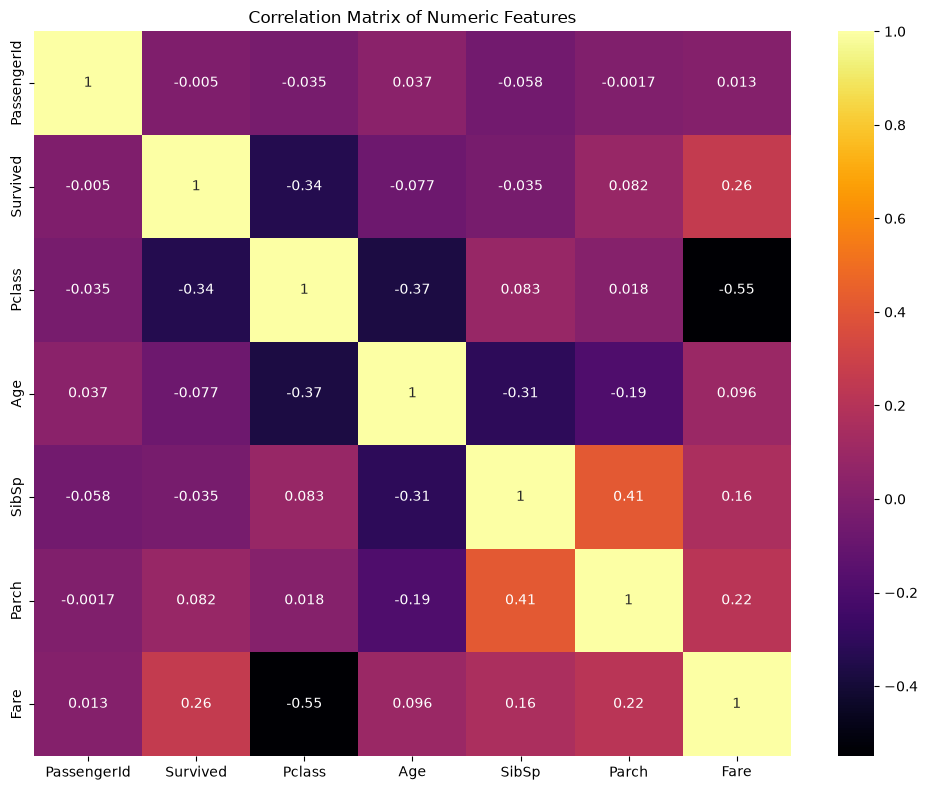

In [6]:
df_numbers = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = df_numbers.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='inferno', annot=correlation_matrix.values, fmt='.2g')
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

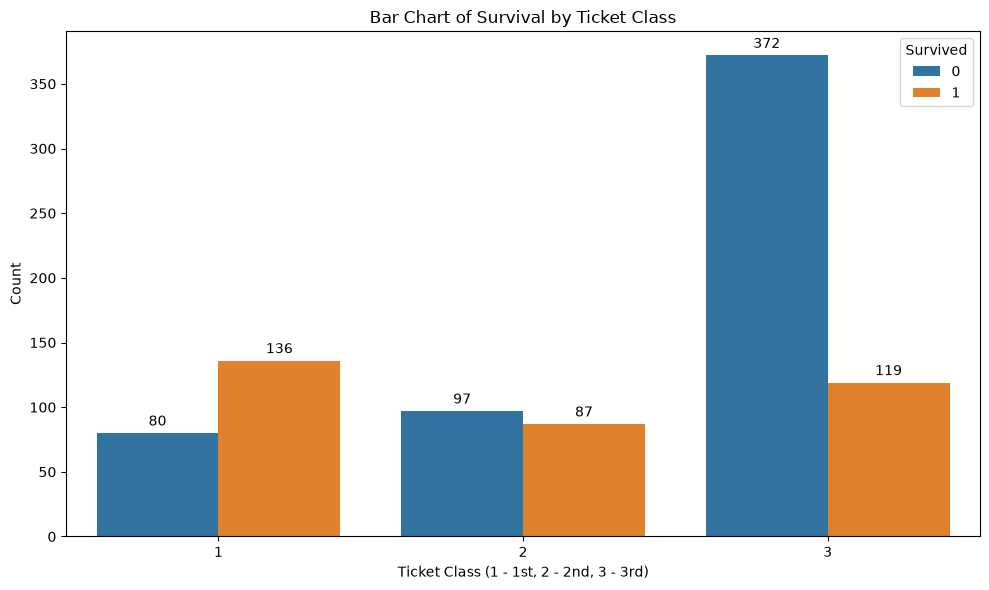

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=df, x='Pclass', hue='Survived', ax=ax)
for container in ax.containers:
    ax.bar_label(container, padding=3)
ax.set_title('Bar Chart of Survival by Ticket Class')
ax.set_xlabel('Ticket Class (1 - 1st, 2 - 2nd, 3 - 3rd)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


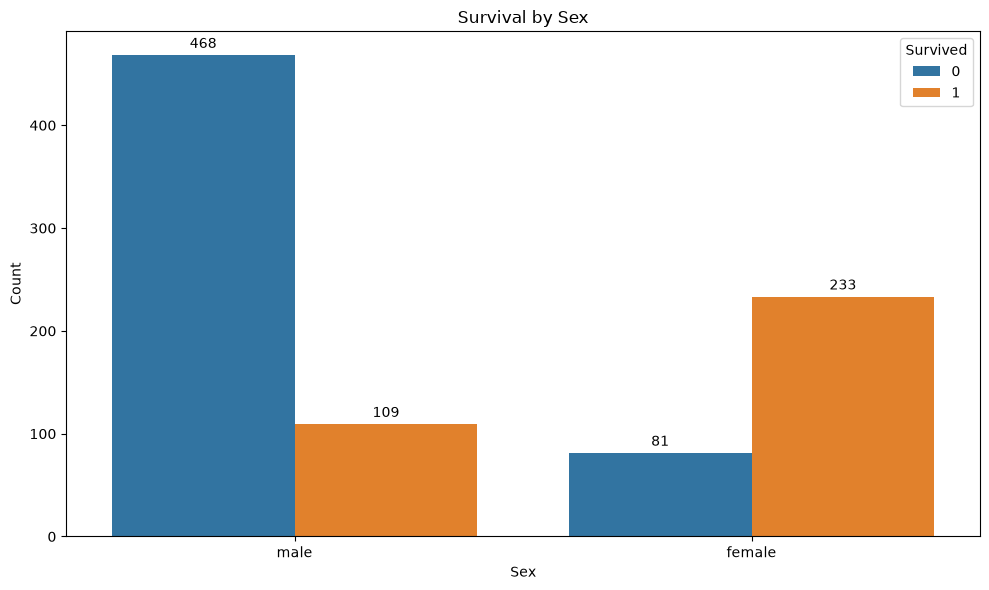

Total number of people: 891
Male survived among all people: 12.23%
Female survived among all people: 26.15%
Male survived among all male: 18.89%
Female survived among all female: 74.20%


In [8]:
fig, ax = plt.subplots(figsize=(10,6))
sns.countplot(data=df, x='Sex', hue='Survived', ax=ax)
for container in ax.containers:
    ax.bar_label(container, padding=3)
ax.set_title('Survival by Sex')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print('Total number of people:', df.shape[0])
df_all = pd.crosstab(df['Sex'], df['Survived'], normalize='all') * 100
print(f'Male survived among all people: {df_all.iloc[1][1]:.2f}%')
print(f'Female survived among all people: {df_all.iloc[0][1]:.2f}%')
df_g = df.groupby('Sex')['Survived'].value_counts(normalize=True) * 100
print(f'Male survived among all male: {df_g.iloc[3]:.2f}%')
print(f'Female survived among all female: {df_g.iloc[0]:.2f}%')

age_grouped
0-14       77
15-21     127
22-60     488
61-100     22
Name: count, dtype: int64


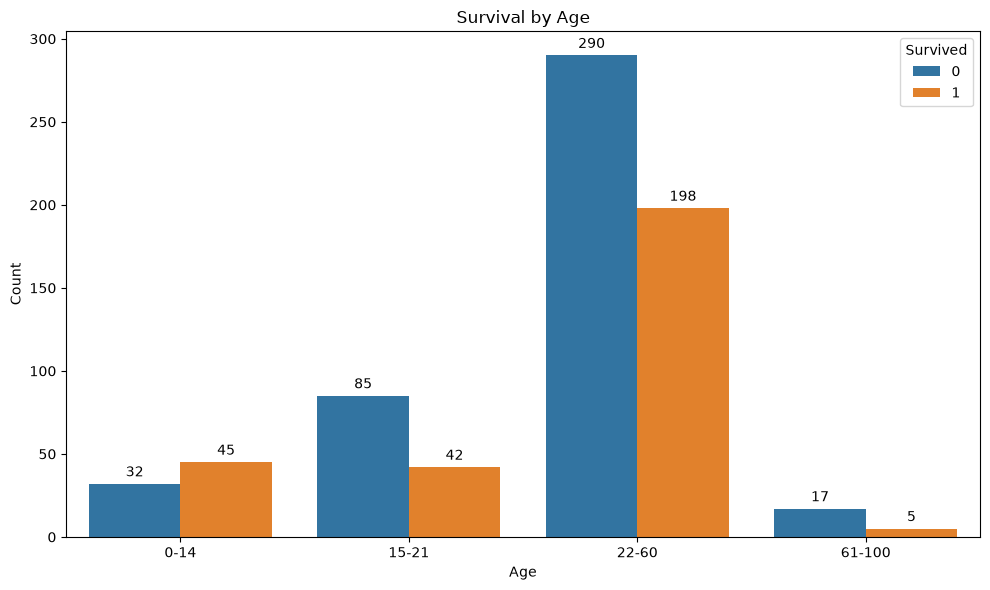

Total number of people: 891
Total number of people whose age is known: 714
--------------------------------------------------------------------------------
Survived people of age 0-14 among its age group: 58.44%
Survived people of age 0-14 among all people: 6.30%
--------------------------------------------------------------------------------
Survived people of age 15-21 among its age group: 33.07%
Survived people of age 15-21 among all people: 5.88%
--------------------------------------------------------------------------------
Survived people of age 22-60 among its age group: 40.57%
Survived people of age 22-60 among all people: 27.73%
--------------------------------------------------------------------------------
Survived people of age 61-100 among its age group: 22.73%
Survived people of age 61-100 among all people: 0.70%


In [9]:
bins = [0, 14, 21, 60, 100]
labels = ['0-14', '15-21', '22-60', '61-100']

df['age_grouped'] = pd.cut(df['Age'], bins=bins, labels=labels).dropna()
counts = df['age_grouped'].value_counts().sort_index()
print(counts)
fig, ax = plt.subplots(figsize=(10,6))
sns.countplot(df, x=df['age_grouped'], hue=df['Survived'], ax=ax)

for container in ax.containers:
    ax.bar_label(container=container, padding=3)
ax.set_title('Survival by Age')
ax.set_ylabel('Count')
ax.set_xlabel('Age')
plt.tight_layout()
plt.show()

print('Total number of people:', df.shape[0])
print("Total number of people whose age is known:", df['Age'].count())
df_g = df.groupby('age_grouped')['Survived'].value_counts(normalize=True) * 100
df_all = pd.crosstab(df['age_grouped'], df['Survived'], normalize='all') * 100
age_groups = df['age_grouped'].cat.categories
for group in age_groups:
    print('-'*80)
    try:
        pct_survived_in_group = df_g.loc[group, 1]
    except:
        pct_survived_in_group = 0.0

    print(f"Survived people of age {group} among its age group: {pct_survived_in_group:.2f}%")
    
    try:
        pct_survived_all = df_all.loc[group, 1]
    except:
        pct_survived_all = 0.0

    print(f"Survived people of age {group} among all people: {pct_survived_all:.2f}%")
    